# Machine Learning #

The dataset used for this project was taken from the UCI Machine Learning Repository and can be accessed at the following link:
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
mvf=["n.a.","?","NA","n/a","na","--","Na","UnKnown"] #Import all the forms the missing values can take
df=pd.read_csv("data.csv", sep=";", na_values=mvf)

In [3]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [4]:
df.shape

(4424, 37)

The database consists of 4424 rows and 37 columns (not all columns are displayed with the "head" command).
The shape means, the database has 4424 observations that correspond to students and it has 37 variables or features.

In [5]:
#Renaming the columns
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [6]:
df.columns=['marital_status', 'appl_mode', 'appl_order', 'course',
       'attendance', 'prev_qual',
       'prev_qual_grade', 'nacionality',
       'mother_qual', 'father_qual',
       'mother_occup', 'father_occup', 'admission_grade',
       'displaced', 'educ_special_needs', 'debtor',
       'tuition_fees_utd', 'gender', 'scholarship_holder',
       'age_enrollment', 'international',
       'cu1s_credited',
       'cu1s_enrolled',
       'cu1s_evaluations',
       'cu1s_approved',
       'cu1s_grade',
       'cu1s_without_evaluations',
       'cu2s_credited',
       'cu2s_enrolled',
       'cu2s_evaluations',
       'cu2s_approved',
       'cu2s_grade',
       'cu2s_without_evaluations', 'unemployment_rate',
       'inflation_rate', 'GDP', 'target']

In [7]:
df.head()

,marital_status,appl_mode,appl_order,course,attendance,prev_qual,prev_qual_grade,nacionality,mother_qual,father_qual,...,cu2s_credited,cu2s_enrolled,cu2s_evaluations,cu2s_approved,cu2s_grade,cu2s_without_evaluations,unemployment_rate,inflation_rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


All the columns have now been renamed which makes the coding neater. The dataset is now ready for characterisation and EDA.

In [8]:
df["GDP"].unique()

array([ 1.74,  0.79, -3.12, -0.92, -4.06,  3.51, -1.7 ,  2.02,  0.32,
        1.79])

In [9]:
df["unemployment_rate"].unique()

array([10.8, 13.9,  9.4, 16.2, 15.5,  8.9, 12.7, 11.1,  7.6, 12.4])

In [10]:
df["inflation_rate"].unique()

array([ 1.4, -0.3, -0.8,  0.3,  2.8,  3.7,  0.6,  2.6,  0.5])

A review of the dataset shows that three variables are economic indicators (GDP, inflation rate, and unemployment rate). However, the data dictionary does not specify what these values represent. It does not specify if they are per capita, how they were assigned to each student, or the time period they correspond to. As a result, these three features will be removed because they do not add value to the analysis.

In [11]:
#Drop the economic indicators
df.drop(["GDP", "unemployment_rate","inflation_rate"], axis=1, inplace=True)

In [12]:
df.shape

(4424, 34)

The dataset has 34 columns because it has lost 3 that were consider irrelevant.

Looking for missing values:

In [13]:
df.isnull().sum()

marital_status              0
appl_mode                   0
appl_order                  0
course                      0
attendance                  0
prev_qual                   0
prev_qual_grade             0
nacionality                 0
mother_qual                 0
father_qual                 0
mother_occup                0
father_occup                0
admission_grade             0
displaced                   0
educ_special_needs          0
debtor                      0
tuition_fees_utd            0
gender                      0
scholarship_holder          0
age_enrollment              0
international               0
cu1s_credited               0
cu1s_enrolled               0
cu1s_evaluations            0
cu1s_approved               0
cu1s_grade                  0
cu1s_without_evaluations    0
cu2s_credited               0
cu2s_enrolled               0
cu2s_evaluations            0
cu2s_approved               0
cu2s_grade                  0
cu2s_without_evaluations    0
target    

No missing values have been found.

In [14]:
df.dtypes

marital_status                int64
appl_mode                     int64
appl_order                    int64
course                        int64
attendance                    int64
prev_qual                     int64
prev_qual_grade             float64
nacionality                   int64
mother_qual                   int64
father_qual                   int64
mother_occup                  int64
father_occup                  int64
admission_grade             float64
displaced                     int64
educ_special_needs            int64
debtor                        int64
tuition_fees_utd              int64
gender                        int64
scholarship_holder            int64
age_enrollment                int64
international                 int64
cu1s_credited                 int64
cu1s_enrolled                 int64
cu1s_evaluations              int64
cu1s_approved                 int64
cu1s_grade                  float64
cu1s_without_evaluations      int64
cu2s_credited               

In [15]:
df["target"].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

Almost all the columns are numerical, some floats and some integers. The target column is an object type because is a categorical value with text and it has not been encoded yet.

Checking for duplicated rows:

In [16]:
duplicate_rows_df = df[df.duplicated()]
print("Number of duplicate rows: ", duplicate_rows_df.shape)

Number of duplicate rows:  (0, 34)


There are no duplicated rows, as it shows 0 duplicated rows and 34 columns.

## Encoding ##

### Target variable ###

The dependent feature has been defined as "target" and it has 3 categories: dropout, enrolled, and graduate.

In [17]:
df["target"].info

<bound method Series.info of 0        Dropout
1       Graduate
2        Dropout
3       Graduate
4       Graduate
          ...   
4419    Graduate
4420     Dropout
4421     Dropout
4422    Graduate
4423    Graduate
Name: target, Length: 4424, dtype: object>

In [18]:
df["target"].unique()

array(['Dropout', 'Graduate', 'Enrolled'], dtype=object)

In [19]:
import sklearn.preprocessing as preproc
import seaborn as sns

In [20]:
#Encoding the target variable
#It will take the values and give them a number
le=preproc.LabelEncoder()

In [21]:
df["target"]=le.fit_transform(df["target"])

In [22]:
df["target"].unique()

array([0, 2, 1])

### Independent variables (one-hot encoding) ###

There are 10 categorical features with many categories: "marital_status", "appl_mode", "appl_order", "course", "prev_qual", "nacionality", "mother_qual", "father_occup", "mother_occup" and "father_occup.

The numbers in these features are not actual numerical values, they are simply labels that represent categories. Neither the order nor the magnitude of these numbers matters for these features. However, any machine learning model will misinterpret them as numerical features. This is why the encoding technique should be applied to these variables. In this way, each of these features will be split into multiple new features, depending on the number of categories, since each category will be converted into a new dummy variable. Nonetheless, this process will make the dataset much larger and cause the number of columns to increase exponentially.

#### Feature: marital_status ####

In [23]:
df["marital_status"].unique()

array([1, 2, 4, 3, 5, 6], dtype=int64)

There are six categories for this feature. This means that instead of one column, it should end up as six columns after encoding. In other words, five additional columns will be added to the dataset.

In [24]:
df=pd.get_dummies(df, columns=["marital_status"], dtype=int)

In [25]:
df.shape

(4424, 39)

Before encoding, the dataset had 34 columns, and after encoding, it has 39, indicating that the 5 additional columns were correctly added.

The rest of the categorical features will follow the same logic as the first one.

#### Feature: appl_mode ####

In [26]:
df["appl_mode"].unique()

array([17, 15,  1, 39, 18, 53, 44, 51, 43,  7, 42, 16,  5,  2, 10, 57, 26,
       27], dtype=int64)

In [27]:
df=pd.get_dummies(df, columns=["appl_mode"], dtype=int)

In [28]:
df.shape

(4424, 56)

#### Rest of the features: "appl_order", "course", "prev_qual", "nacionality", "mother_qual", "father_occup", "mother_occup" and "father_occup". ####

In [29]:
df=pd.get_dummies(df, columns=["appl_order", "course","prev_qual","nacionality","mother_qual","father_occup","mother_occup","father_occup"], dtype=int)

In [30]:
df.shape

(4424, 265)

After encoding all the categorical features, the database ended up with 265 features instead of the 37 from the beginning. Now, the database consists in dummy variables and numerical variables.

## Detecting outliers ##

The majority of the features in this database are categorical, nonetheless there are some numerical features that are worthy to take a look at. Also, there are some of the features that even though they are numerical, they are also constrained in an interval (the ones that describe grades). This features should not represent a problem in terms of outliers

### Feature: age_enrollment ###

<Axes: xlabel='age_enrollment'>

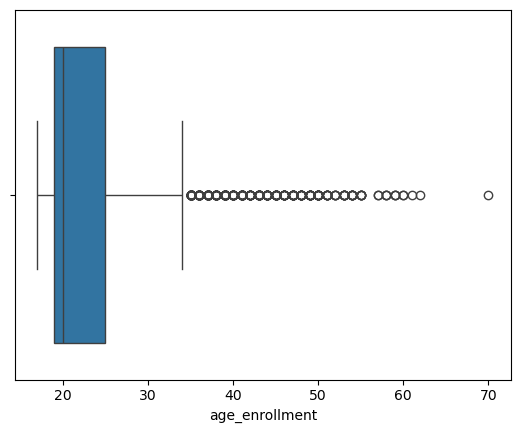

In [31]:
sns.boxplot(x=df["age_enrollment"])

The plot shows that the feature representing the students’ ages has a median of 20 years. Nonetheless, it also reveals some outliers ranging from 35 to 70 years old. This suggests that a 70-year-old person enrolled in college, which is perfectly possible in real life. However, it could have also been an entry error. What is certain is that these values are outliers.

### Feature: prev_qual_grade ###

<Axes: xlabel='prev_qual_grade'>

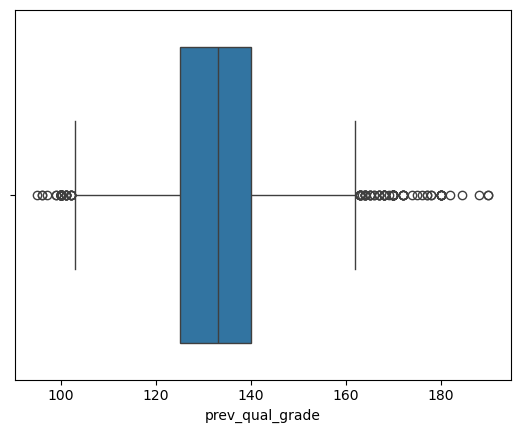

In [32]:
sns.boxplot(x=df["prev_qual_grade"])

### Feature: admission_grade ###

<Axes: xlabel='admission_grade'>

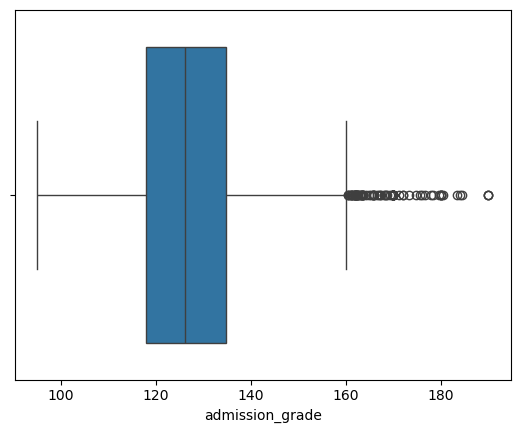

In [33]:
sns.boxplot(x=df["admission_grade"])

### Feature: cu1s_grade ###

<Axes: xlabel='cu1s_grade'>

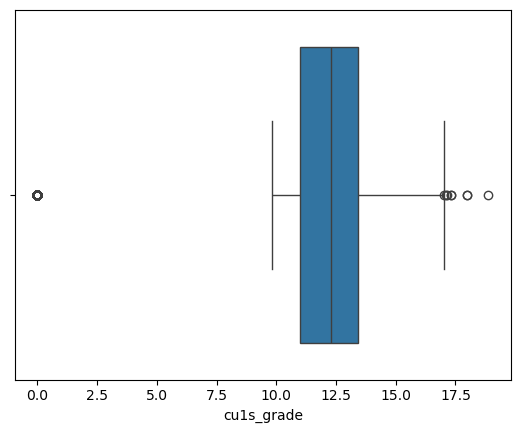

In [34]:
sns.boxplot(x=df["cu1s_grade"])

### Feature: cu2_grade ###

<Axes: xlabel='cu2s_grade'>

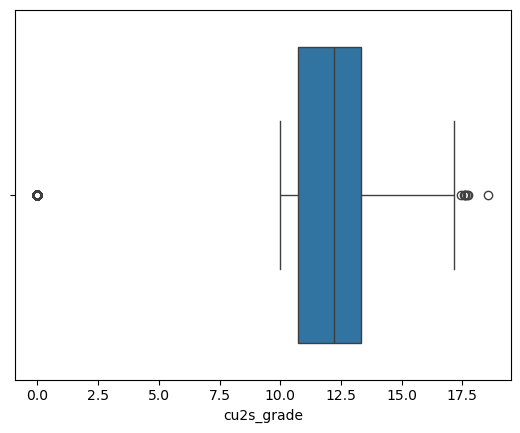

In [35]:
sns.boxplot(x=df["cu2s_grade"])

Exploring the variables that describe the number of academic units in any form shows that they follow a specific distribution and take on a limited set of values. For this reason, these types of variables will not be considered when looking for outliers.

After reviewing the features relevant for detecting outliers, it can be concluded that the grades are all interval variables. Therefore, the outliers simply represent students with very high or very low marks, which are valuable to retain for the analysis, as they might help the model better identify the determinants that influence a student to dropout. Similarly, the student’s age should not be considered noise, since it is an important factor to analyze when exploring whether age influences the likelihood of dropping out of college.

## Imbalanced Data ##

In [36]:
#Installing library
#!pip install imbalanced-learn

In [37]:
#Import libraries
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

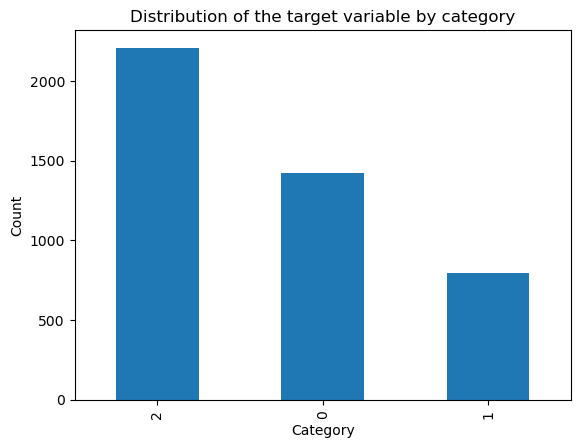

In [38]:
#Plotting the target variable
pd.Series(df["target"]).value_counts().plot(kind="bar")
plt.title("Distribution of the target variable by category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

The graph shows that the data is imbalanced. Category 2 has more than twice the number of observations as Category 1. Therefore, it is necessary to balance the data before applying any machine learning model or performing dimensionality reduction.

In [39]:
#Dividing between target and independent variables
X = df.drop("target", axis=1)
y = df["target"]

print("Original class distribution:", Counter(y))

Original class distribution: Counter({2: 2209, 0: 1421, 1: 794})


In [40]:
#Over-sampling with SMOTE (increase minority class)
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

print("After SMOTE over-sampling:", Counter(y_smote))

After SMOTE over-sampling: Counter({0: 2209, 2: 2209, 1: 2209})


In [41]:
#Merging the datasets againg to continue the process
df= pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name="target")],
    axis=1
)

In [42]:
df.shape

(6627, 265)

## Scaling ##

After reviewing all the independent features, it can be observed that the majority are categorical. Therefore, scaling is not applicable to these variables. On another hand, most of the numerical features have values ranging from 0 to 70 (student's age) or even less (for example, 0 to 20 for the semester's average grade). However, the admission grade and the previous qualification grade are measured on a scale from 0 to 200. This means their range is more than double that of the other numerical features. Consequently, it would be appropriate to scale them and get the same scale for all the numerical features.

Although some numerical features, such as age or the curricular unit grades, are skewed, others exhibit a quasi-Gaussian distribution, such as the features describing the grades. Standardization will be used as the scaling method for all the numerical values because all the independent variables need to have the same scale before applying any machine learning model and because the outliers were not consider problematic.

### Feature: prev_qual_grade ###

In [43]:
import seaborn as sns

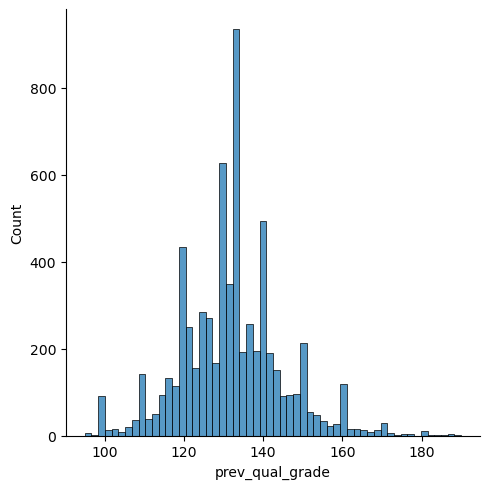

In [44]:
sns.displot(df, x="prev_qual_grade");

In [45]:
df["prev_qual_grade"]=preproc.StandardScaler().fit_transform(df[["prev_qual_grade"]])

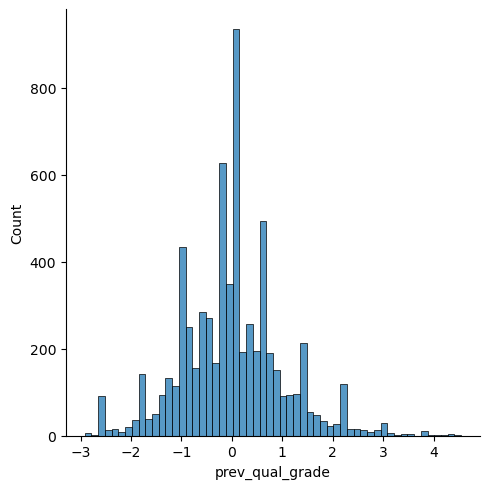

In [46]:
sns.displot(df, x="prev_qual_grade");

### Feature: admission_grade ###

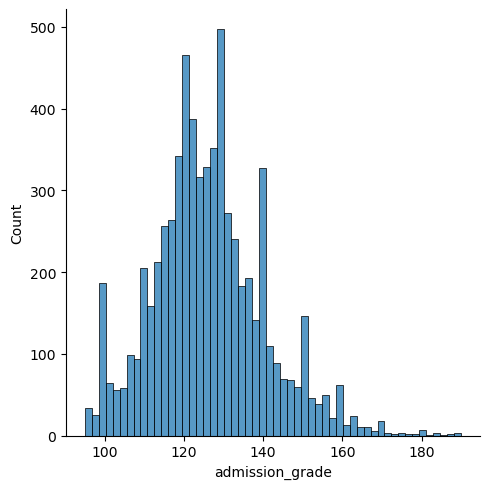

In [47]:
sns.displot(df, x="admission_grade");

In [48]:
df["admission_grade"]=preproc.StandardScaler().fit_transform(df[["admission_grade"]])

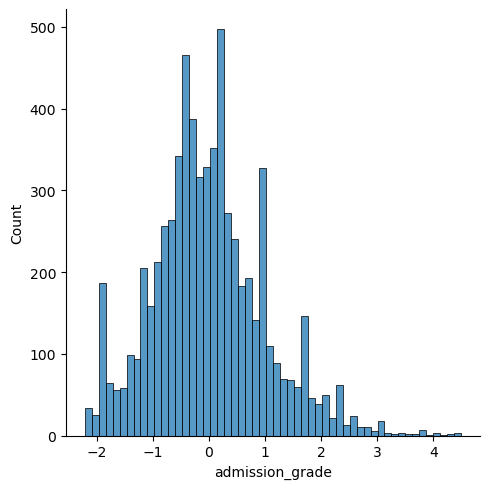

In [49]:
sns.displot(df, x="admission_grade");

### Rest of the numerical features ###

In [50]:
scale_cols = ["age_enrollment","cu1s_credited","cu1s_enrolled","cu1s_evaluations","cu1s_approved","cu1s_grade","cu1s_without_evaluations","cu2s_credited","cu2s_enrolled","cu2s_evaluations","cu2s_approved","cu2s_grade","cu2s_without_evaluations"]
df[scale_cols].describe()

,age_enrollment,cu1s_credited,cu1s_enrolled,cu1s_evaluations,cu1s_approved,cu1s_grade,cu1s_without_evaluations,cu2s_credited,cu2s_enrolled,cu2s_evaluations,cu2s_approved,cu2s_grade,cu2s_without_evaluations
count,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000,6627.000000
mean,23.097933,0.576128,6.020220,8.240078,4.230874,10.322505,0.120266,0.425079,5.986419,8.054776,3.941753,9.884164,0.137468
std,7.343081,2.082959,2.278036,4.012037,2.920642,4.888961,0.630633,1.677138,2.035705,3.871836,2.851901,5.235613,0.696870
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,5.000000,6.000000,2.000000,10.857143,0.000000,0.000000,5.000000,6.000000,2.000000,10.501066,0.000000
50%,20.000000,0.000000,6.000000,8.000000,5.000000,12.064840,0.000000,0.000000,6.000000,8.000000,4.000000,12.000000,0.000000
75%,25.000000,0.000000,6.000000,10.000000,6.000000,13.125000,0.000000,0.000000,6.000000,10.000000,6.000000,13.037854,0.000000
max,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


In [51]:
df[scale_cols] = preproc.StandardScaler().fit_transform(df[scale_cols])

In [52]:
df[scale_cols].describe()

,age_enrollment,cu1s_credited,cu1s_enrolled,cu1s_evaluations,cu1s_approved,cu1s_grade,cu1s_without_evaluations,cu2s_credited,cu2s_enrolled,cu2s_evaluations,cu2s_approved,cu2s_grade,cu2s_without_evaluations
count,6.627000e+03,6627.000000,6.627000e+03,6.627000e+03,6.627000e+03,6.627000e+03,6.627000e+03,6627.000000,6.627000e+03,6.627000e+03,6.627000e+03,6.627000e+03,6.627000e+03
mean,8.148672e-17,0.000000,-1.200857e-16,5.200139e-17,-6.862039e-17,5.875621e-16,2.358826e-17,0.000000,2.230163e-16,-1.565403e-16,1.715510e-17,2.487489e-16,-9.649743e-18
std,1.000075e+00,1.000075,1.000075e+00,1.000075e+00,1.000075e+00,1.000075e+00,1.000075e+00,1.000075,1.000075e+00,1.000075e+00,1.000075e+00,1.000075e+00,1.000075e+00
min,-8.304951e-01,-0.276612,-2.642923e+00,-2.053994e+00,-1.448720e+00,-2.111550e+00,-1.907205e-01,-0.253474,-2.940932e+00,-2.080508e+00,-1.382254e+00,-1.888014e+00,-1.972798e-01
25%,-5.581093e-01,-0.276612,-4.478846e-01,-5.583815e-01,-7.638876e-01,1.093643e-01,-1.907205e-01,-0.253474,-4.845955e-01,-5.307381e-01,-6.809142e-01,1.178368e-01,-1.972798e-01
50%,-4.219164e-01,-0.276612,-8.876872e-03,-5.984405e-02,2.633614e-01,3.564084e-01,-1.907205e-01,-0.253474,6.671806e-03,-1.414834e-02,2.042531e-02,4.041542e-01,-1.972798e-01
75%,2.590481e-01,-0.276612,-8.876872e-03,4.386934e-01,6.057777e-01,5.732724e-01,-1.907205e-01,-0.253474,6.671806e-03,5.024415e-01,7.217648e-01,6.023989e-01,-1.972798e-01
max,6.387729e+00,9.325838,8.771277e+00,9.163099e+00,7.454104e+00,1.749480e+00,1.883921e+01,11.076206,8.358216e+00,6.443224e+00,5.631141e+00,1.659389e+00,1.702388e+01


After scaling, all the numerical features show a mean value of 0 and a variance of 1. However, the actual values have different ranges. 

## Dimensionality Reduction ##

In [53]:
from sklearn.decomposition import PCA

In [54]:
df.shape

(6627, 265)

The original dataset contained 37 columns, which was reduced to 34 after removing the economic indicators. Since the dataset includes many categorical features, various encoding methods were applied, including one-hot encoding, which generated a large number of additional dummy variables. As a result, the dataset now has 265 features while keeping its 6627 observations.

One of the algorithms used to reduce dimensionality is PCA (Principal Component Analysis). This algorithm should be applied only to the independent variables, so the target variable must be excluded before applying it.

In [55]:
df_no_target=df.drop(columns=["target"])

In [56]:
#Checking the number of features
df_no_target.shape

(6627, 264)

In [57]:
#Applying PCA algorithm
pca=PCA().fit(df_no_target)

Text(0, 0.5, 'Cumulative Explained Variance')

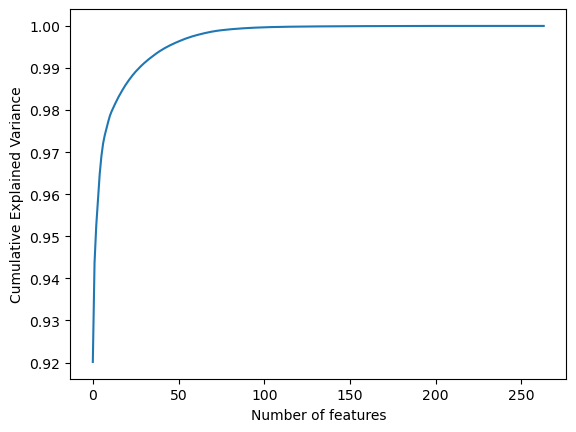

In [58]:
#Plotting the number of features
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of features")
plt.ylabel("Cumulative Explained Variance")

The PCA algorithm indicates that, to retain 99.5% of the variance, a minimum of 50 features is required. Therefore, starting from 250 features, applying PCA reduces the dimensionality to just 50 features. In other words, only 20% of the original features are needed to explain 99.5% of the variance.

In [59]:
#Keeping just 50 features
pca=PCA(50)
projected=pca.fit_transform(df_no_target)

In [60]:
projected.shape

(6627, 50)

The 50 features required to explain 99.5% of the variance are not the original features from the dataset. These 50 features are generated from the previous 250 features and do not retain the original values. Instead, they encode the variance from the original dataset. the dimensionality has been reduced, but the variance has been preserved.

In [61]:
#To name the new columns
cols_names = [f"C{i+1}" for i in range(50)]
df_pca = pd.DataFrame(projected, columns=cols_names)

In [62]:
df_pca.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C41,C42,C43,C44,C45,C46,C47,C48,C49,C50
0,-9.953144,-5.463668,-0.680537,0.162121,-0.885390,-1.520827,-0.504181,-1.934089,-0.083945,0.010487,...,0.172557,0.089445,-0.248044,0.018438,0.151460,0.002965,0.124896,-0.019814,-0.167099,-0.036929
1,-18.968858,0.414015,1.502182,2.133937,0.358498,0.097092,-0.363111,0.368177,0.165199,-0.684115,...,-0.544420,-0.079611,-0.079435,-0.034845,0.009131,-0.140206,0.040134,0.280772,-0.087117,-0.371044
2,15.061657,-3.564135,-1.210263,0.105332,-1.099803,-2.335400,-0.453047,0.683089,-0.177261,1.245962,...,-0.322829,-0.055238,-0.195952,0.148324,0.091415,-0.256012,0.027912,0.052574,-0.009201,-0.225133
3,15.044053,0.526628,1.261176,-1.176041,0.082764,-0.473118,0.119289,-0.193450,0.091244,0.242054,...,0.178409,0.224539,-0.600246,0.424634,0.114406,0.388635,-0.091673,-0.014064,-0.411191,0.490083
4,16.134581,0.372964,-0.696032,-0.690572,-1.030762,2.473189,-2.712751,-0.885137,-0.601597,1.963401,...,-0.026789,0.107000,0.140412,-0.016007,0.222985,-0.212512,-0.080608,-0.210239,-0.108921,-0.038422


In [63]:
#To merge with the target variable
df_pca["target"]=df["target"]

In [64]:
df_pca.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C42,C43,C44,C45,C46,C47,C48,C49,C50,target
0,-9.953144,-5.463668,-0.680537,0.162121,-0.885390,-1.520827,-0.504181,-1.934089,-0.083945,0.010487,...,0.089445,-0.248044,0.018438,0.151460,0.002965,0.124896,-0.019814,-0.167099,-0.036929,0
1,-18.968858,0.414015,1.502182,2.133937,0.358498,0.097092,-0.363111,0.368177,0.165199,-0.684115,...,-0.079611,-0.079435,-0.034845,0.009131,-0.140206,0.040134,0.280772,-0.087117,-0.371044,2
2,15.061657,-3.564135,-1.210263,0.105332,-1.099803,-2.335400,-0.453047,0.683089,-0.177261,1.245962,...,-0.055238,-0.195952,0.148324,0.091415,-0.256012,0.027912,0.052574,-0.009201,-0.225133,0
3,15.044053,0.526628,1.261176,-1.176041,0.082764,-0.473118,0.119289,-0.193450,0.091244,0.242054,...,0.224539,-0.600246,0.424634,0.114406,0.388635,-0.091673,-0.014064,-0.411191,0.490083,2
4,16.134581,0.372964,-0.696032,-0.690572,-1.030762,2.473189,-2.712751,-0.885137,-0.601597,1.963401,...,0.107000,0.140412,-0.016007,0.222985,-0.212512,-0.080608,-0.210239,-0.108921,-0.038422,2


## Machine Learning Models ##

In [65]:
#Importing libraries

In [66]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix

In [67]:
# Define features and target variable
X = df.drop(columns="target")
y = df["target"]

In [68]:
#Independent features
X.shape

(6627, 264)

In [69]:
#Target variable
y.shape

(6627,)

### 10% Training Split ###

In [70]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10, random_state = 42)

In [71]:
#Shape of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5964, 264), (663, 264), (5964,), (663,))

#### k-Nearest Neighbours Model (KNN) ####

In [72]:
#Create KNN Classifier
kNN = KNeighborsClassifier(n_neighbors = 3)
#Train the model
kNN.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = kNN.predict(X_test)

In [73]:
#Accuracy
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.76


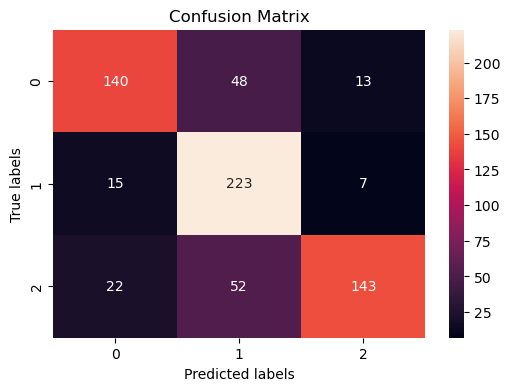

In [74]:
#Confusion matrix
y_predict = kNN.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [75]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.79      0.70      0.74       201
           1       0.69      0.91      0.79       245
           2       0.88      0.66      0.75       217

    accuracy                           0.76       663
   macro avg       0.79      0.76      0.76       663
weighted avg       0.78      0.76      0.76       663



#### Decision Trees ####

In [76]:
#Classifer object
clf = DecisionTreeClassifier(criterion='gini', max_depth = 3, random_state = 42)
#Train Decision Tree Classifer
clf = clf.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [77]:
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.70


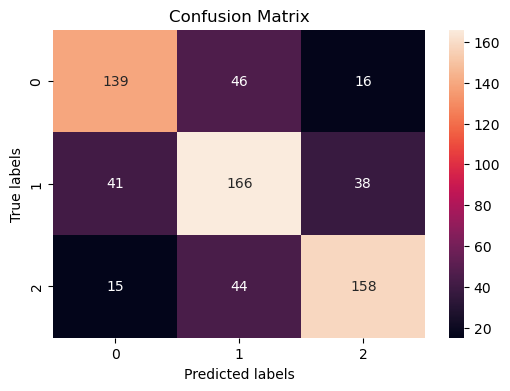

In [78]:
#Confusion matrix
y_predict = clf.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [79]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       201
           1       0.65      0.68      0.66       245
           2       0.75      0.73      0.74       217

    accuracy                           0.70       663
   macro avg       0.70      0.70      0.70       663
weighted avg       0.70      0.70      0.70       663



#### Random Forest ####

In [80]:
#Create a Gaussian Classifier
clf_RF = RandomForestClassifier(n_estimators = 100, random_state = 42)
#Train the model
clf_RF.fit(X_train, y_train)
#Predict
y_pred = clf_RF.predict(X_test)

In [81]:
#Accuracy
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.82


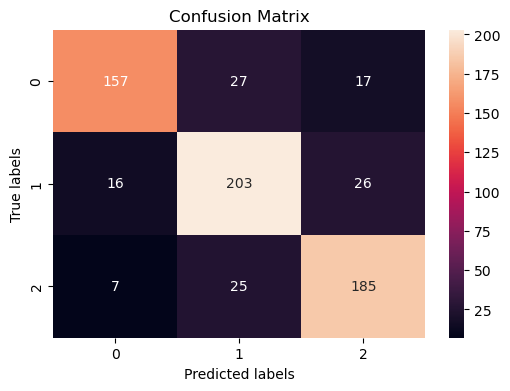

In [82]:
#Confusion matrix
y_predict = clf_RF.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [83]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.87      0.78      0.82       201
           1       0.80      0.83      0.81       245
           2       0.81      0.85      0.83       217

    accuracy                           0.82       663
   macro avg       0.83      0.82      0.82       663
weighted avg       0.82      0.82      0.82       663



### 15% Training Split ###

In [84]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42)

In [85]:
#Shape of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5632, 264), (995, 264), (5632,), (995,))

#### k-Nearest Neighbours Model (KNN) ####

In [86]:
#Create KNN Classifier
kNN = KNeighborsClassifier(n_neighbors = 3)
#Train the model
kNN.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = kNN.predict(X_test)

In [87]:
#Accuracy
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.76


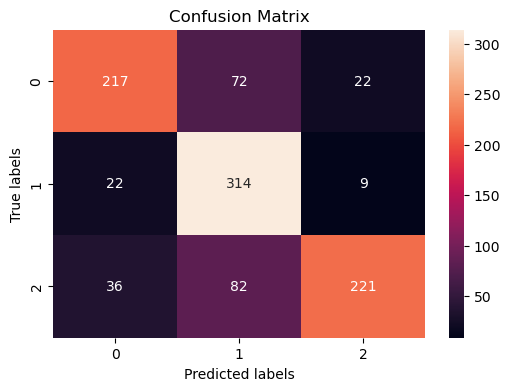

In [88]:
#Confusion matrix
y_predict = kNN.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [89]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.79      0.70      0.74       311
           1       0.67      0.91      0.77       345
           2       0.88      0.65      0.75       339

    accuracy                           0.76       995
   macro avg       0.78      0.75      0.75       995
weighted avg       0.78      0.76      0.75       995



#### Decision Trees ####

In [90]:
#Classifer object
clf = DecisionTreeClassifier(criterion='gini', max_depth = 3, random_state = 42)
#Train Decision Tree Classifer
clf = clf.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [91]:
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.71


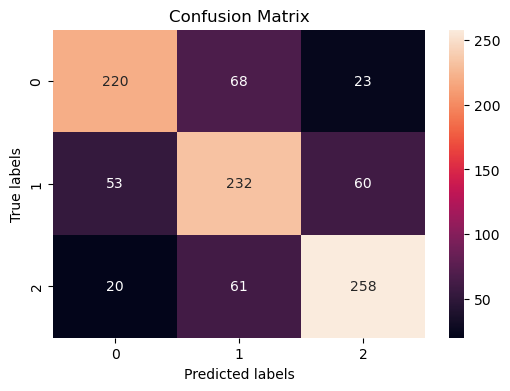

In [92]:
#Confusion matrix
y_predict = clf.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [93]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.75      0.71      0.73       311
           1       0.64      0.67      0.66       345
           2       0.76      0.76      0.76       339

    accuracy                           0.71       995
   macro avg       0.72      0.71      0.71       995
weighted avg       0.72      0.71      0.71       995



#### Random Forest ####

In [94]:
#Create a Gaussian Classifier
clf_RF = RandomForestClassifier(n_estimators = 100, random_state = 42)
#Train the model
clf_RF.fit(X_train, y_train)
#Predict
y_pred = clf_RF.predict(X_test)

In [95]:
#Accuracy
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.81


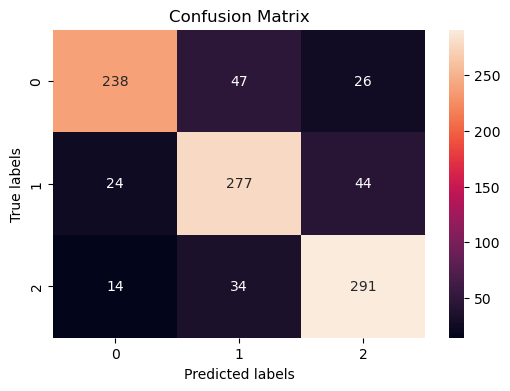

In [96]:
#Confusion matrix
y_predict = clf_RF.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [97]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.86      0.77      0.81       311
           1       0.77      0.80      0.79       345
           2       0.81      0.86      0.83       339

    accuracy                           0.81       995
   macro avg       0.81      0.81      0.81       995
weighted avg       0.81      0.81      0.81       995



### 20% Training Split ###

In [98]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [99]:
#Shape of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5301, 264), (1326, 264), (5301,), (1326,))

#### k-Nearest Neighbours Model (KNN) ####

In [100]:
#Create KNN Classifier
kNN = KNeighborsClassifier(n_neighbors = 3)
#Train the model
kNN.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = kNN.predict(X_test)

In [101]:
#Accuracy
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.74


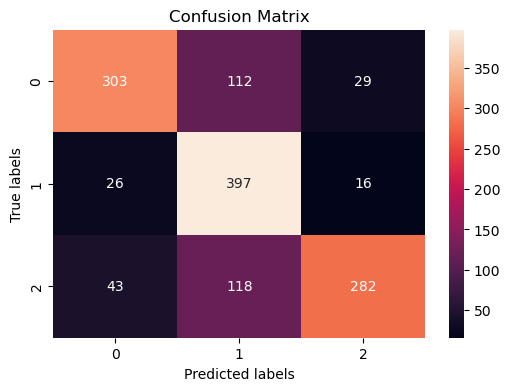

In [102]:
#Confusion matrix
y_predict = kNN.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [103]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.81      0.68      0.74       444
           1       0.63      0.90      0.74       439
           2       0.86      0.64      0.73       443

    accuracy                           0.74      1326
   macro avg       0.77      0.74      0.74      1326
weighted avg       0.77      0.74      0.74      1326



#### Decision Trees ####

In [104]:
#Classifer object
clf = DecisionTreeClassifier(criterion='gini', max_depth = 3, random_state = 42)
#Train Decision Tree Classifer
clf = clf.fit(X_train, y_train)
#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [105]:
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.70


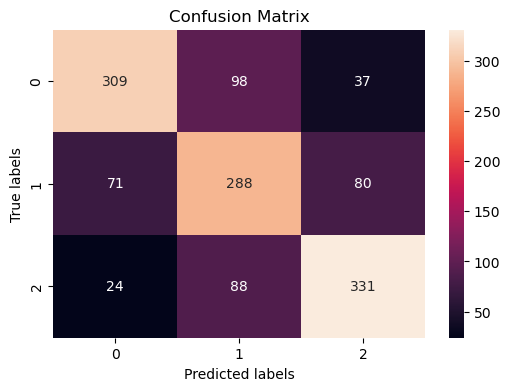

In [106]:
#Confusion matrix
y_predict = clf.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [107]:
#Classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.76      0.70      0.73       444
           1       0.61      0.66      0.63       439
           2       0.74      0.75      0.74       443

    accuracy                           0.70      1326
   macro avg       0.70      0.70      0.70      1326
weighted avg       0.70      0.70      0.70      1326



#### Random Forest ####

In [108]:
#Create a Gaussian Classifier
clf_RF = RandomForestClassifier(n_estimators = 100, random_state = 42)
#Train the model
clf_RF.fit(X_train, y_train)
#Predict
y_pred = clf_RF.predict(X_test)

In [109]:
#Accuracy
print("Accuracy: {:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.81


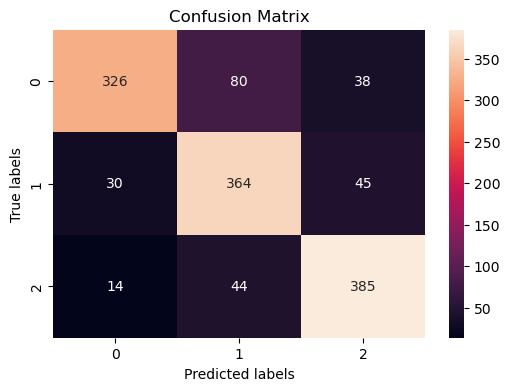

In [110]:
#Confusion matrix
y_predict = clf_RF.predict(X_test)
cm = confusion_matrix(y_test, y_predict)
#Plot confusion matrix with integers using seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [111]:
# Display the classification report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.88      0.73      0.80       444
           1       0.75      0.83      0.79       439
           2       0.82      0.87      0.85       443

    accuracy                           0.81      1326
   macro avg       0.82      0.81      0.81      1326
weighted avg       0.82      0.81      0.81      1326



Because two models show the highest accuracy with the training split of 10%, it has been chosen to compare between models.

In [112]:
#Training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10, random_state = 42)

In [113]:
#Shape of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5964, 264), (663, 264), (5964,), (663,))

In [114]:
#Define classifiers for ML models
classifiers = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

In [115]:
# Train and evaluate ML model classifiers for Obesity dataset
results = []
for name, classifier in classifiers.items():
    # Train the classifier
    classifier.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = classifier.predict(X_test)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']
    
    # Append results
    results.append([name, accuracy, precision, recall, f1_score])

In [116]:
# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print("Model Performance Metrics on Test Set:")
print(results_df)

Model Performance Metrics on Test Set:
           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.763198   0.782060  0.763198  0.761066
1  Decision Tree  0.751131   0.752999  0.751131  0.751539
2  Random Forest  0.822021   0.824179  0.822021  0.822052


In [117]:
#Cross-validation for accuracy on the full dataset
cv_results = []
for name, classifier in classifiers.items():
    cv_scores = cross_val_score(classifier, X, y, cv=5, scoring='accuracy')
    cv_results.append([name, cv_scores.mean()])

#Display cross-validation results
cv_results_df = pd.DataFrame(cv_results, columns=["Model", "Mean CV Accuracy"])
print("\nCross-Validation Accuracy Scores:")
print(cv_results_df)


Cross-Validation Accuracy Scores:
           Model  Mean CV Accuracy
0            KNN          0.732769
1  Decision Tree          0.725235
2  Random Forest          0.808077


The Random Forest model displays the highest accuracy.

### Hyperparameter Tuning ###

#### GridSearchCV ####

In [118]:
# Define hyperparameter grids for each classifier
param_grids = {
    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [1, 2, 5],
        "min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "n_estimators": [200, 300, 400],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [1, 2, 5],
        "min_samples_leaf": [1, 2, 4],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
}

In [119]:
#Applying GridSearchCV for each classifier and evaluate performance metric scores
results = []
for name, classifier in classifiers.items():
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(estimator=classifier, param_grid=param_grids[name], cv = 5, n_jobs = -1, verbose = 2)
    grid_search.fit(X_train, y_train)
    
    # Best model from grid search
    best_model = grid_search.best_estimator_
    
    # Predict on the test set with the best model
    y_pred = best_model.predict(X_test)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']
    
    # Append results
    results.append([name, accuracy, precision, recall, f1_score, grid_search.best_params_])

Running GridSearchCV for KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [120]:
#As a DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "Best Parameters"])
print("Model Performance Metrics on Test Set after GridSearchCV:")
print(results_df)

Model Performance Metrics on Test Set after GridSearchCV:
           Model  Accuracy  Precision    Recall  F1 Score  \
0            KNN  0.763198   0.782060  0.763198  0.761066   
1  Decision Tree  0.752640   0.752466  0.752640  0.752528   
2  Random Forest  0.817496   0.821024  0.817496  0.817758   

                                     Best Parameters  
0            {'algorithm': 'auto', 'n_neighbors': 3}  
1  {'max_depth': 10, 'min_samples_leaf': 1, 'min_...  
2  {'max_depth': None, 'min_samples_leaf': 1, 'mi...  


In [121]:
#Cross-validation for accuracy on the full dataset using best models
cv_results = []
for name, classifier in classifiers.items():
    # Get the best model from GridSearchCV
    grid_search = GridSearchCV(estimator=classifier, param_grid=param_grids[name], cv=5, n_jobs=-1, verbose=2)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    
    cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
    cv_results.append([name, cv_scores.mean()])

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [122]:
#Cross-validation results
cv_results_df = pd.DataFrame(cv_results, columns=["Model", "Mean CV Accuracy"])
print("\nCross-Validation Accuracy Scores after GridSearchCV:")
print(cv_results_df)


Cross-Validation Accuracy Scores after GridSearchCV:
           Model  Mean CV Accuracy
0            KNN          0.732769
1  Decision Tree          0.736244
2  Random Forest          0.813659


### Comparing models ###

Running GridSearchCV for KNN...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


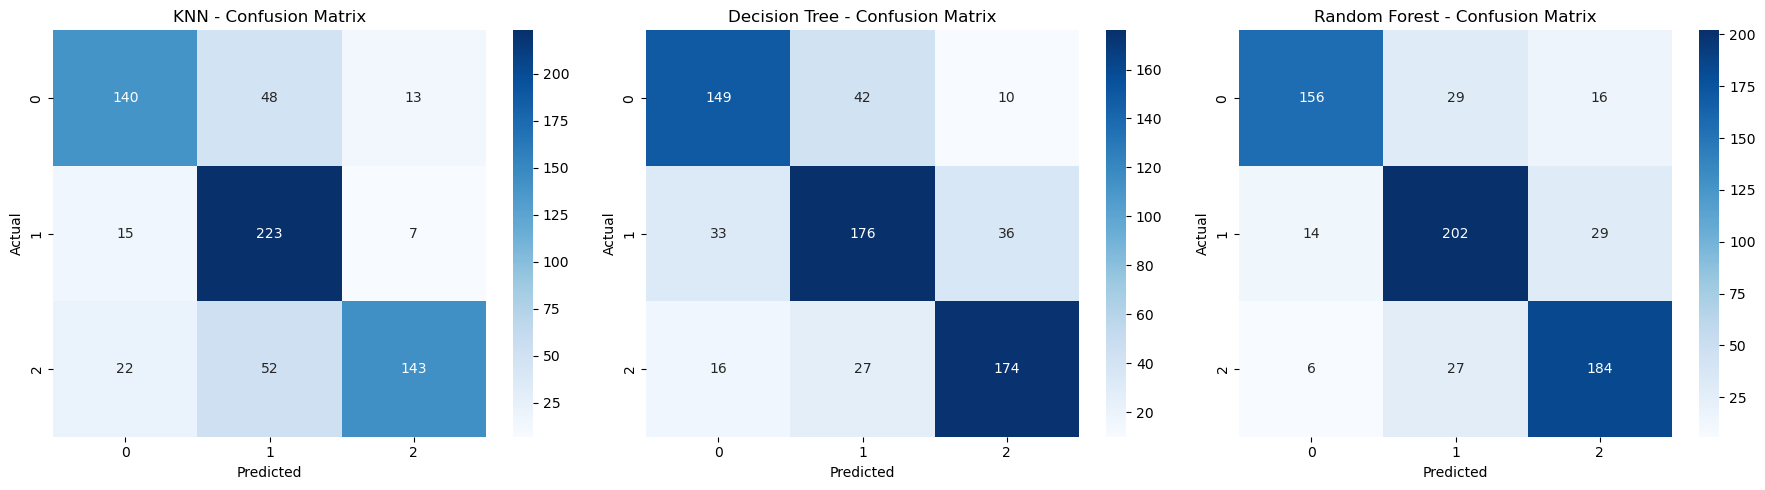

In [123]:
conf_matrices = []
model_names = []

for name, classifier in classifiers.items():
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(estimator=classifier, param_grid=param_grids[name], cv=5, n_jobs=-1, verbose=2)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Store confusion matrix and model name
    conf_matrices.append(confusion_matrix(y_test, y_pred))
    model_names.append(name)

#Plot all confusion matrices
fig, axes = plt.subplots(1, len(conf_matrices), figsize=(6*len(conf_matrices), 5))
if len(conf_matrices) == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    sns.heatmap(conf_matrices[i], annot=True, cmap='Blues', fmt='g', ax=ax)
    ax.set_title(f'{model_names[i]} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()